## sinter_sampler.py

In [1]:
import stim
import sinter
from corrqec2.sampling import SinterSampler

# Experiment
experiment_name = "SurfaceCodeStability"
experiment_args = {'distance': 8, 'rounds': '3d', 'basis': 'Z'}

# Noise model
noise_model_name = "StormModel"
p_gate = 0.01
gate_noise = {
    #'after_identity_depolarization': p_gate,
    'after_clifford_depolarization': p_gate,
    'before_measure_flip_probability': p_gate,
    #'after_reset_flip_probability': p_gate,
}
noise_model_params = {
        'a': 0.01,
        'b': 0.5,
        'emissions': [[1., 0., 0., 0.], [0.25, 0.25, 0.25, 0.25]],
    }
noisy_qubit_types = 'syndrome'
noise_model_args = {
    'model_params': noise_model_params,
    'gate_noise': gate_noise,
    'noisy_qubit_types': noisy_qubit_types,
}

# Decoder
decoder_name = "Pymatching"
marginalized_dem = True

min_batch_size = 1000

metadata = {
    "experiment": experiment_name,
    "experiment_args": experiment_args,
    "noise_model": noise_model_name,
    "noise_model_args": noise_model_args,
    "decoder": decoder_name,
    "min_batch_size": min_batch_size,
    "marginalized_detector_error_model": marginalized_dem,
}

task = sinter.Task(circuit=stim.Circuit(), json_metadata=metadata)
sampler = SinterSampler()

In [2]:
num_workers = 4
n_shots = 10000
print_progress = True

stats = sinter.collect(tasks=[task], num_workers=num_workers, decoders='custom_sampler', custom_decoders={'custom_sampler': sampler}, max_shots=n_shots, print_progress=print_progress)

Starting 4 workers...
1 tasks left:
  workers        decoder eta shots_left errors_seen json_metadata                                                                                                                                                                                                                                                                                                                                                                                                                                              
        4 custom_sampler   ?       9000          15 experiment=SurfaceCodeStability,experiment_args={'distance': 8, 'rounds': '3d', 'basis': 'Z'},noise_model=StormModel,noise_model_args={'model_params': {'a': 0.01, 'b': 0.5, 'emissions': [[1.0, 0.0, 0.0, 0.0], [0.25, 0.25, 0.25, 0.25]]}, 'gate_noise': {'after_clifford_depolarization': 0.01, 'before_measure_flip_probability': 0.01}, 'noisy_qubit_types': 'syndrome'},decoder=Pymatching,min_batch_size=1000,marginalize

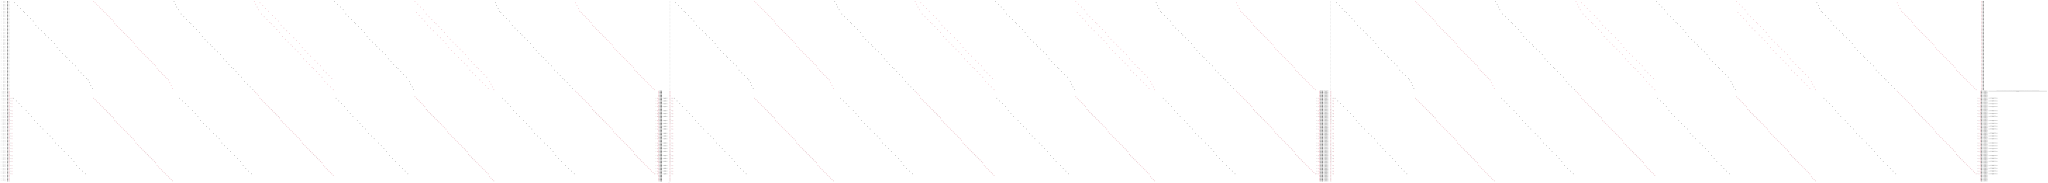

In [3]:
from corrqec2.noisemodels import StormModel
from corrqec2.experiments import SurfaceCodeMemory, SurfaceCodeStability

experiment = SurfaceCodeStability(**experiment_args)
model = StormModel(**noise_model_args)

model.gen_marginalized_circuit(experiment).diagram('timeline-svg')